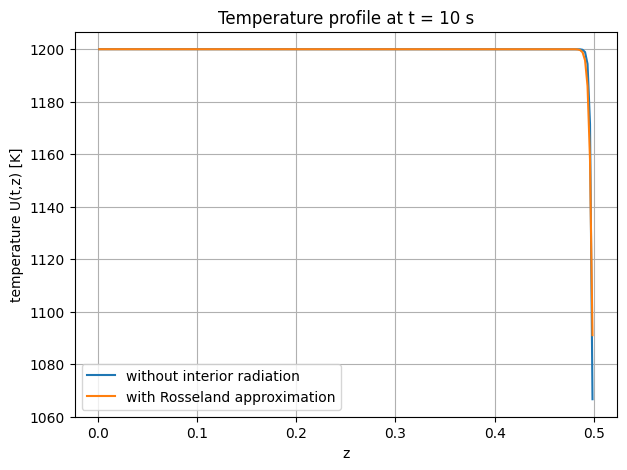

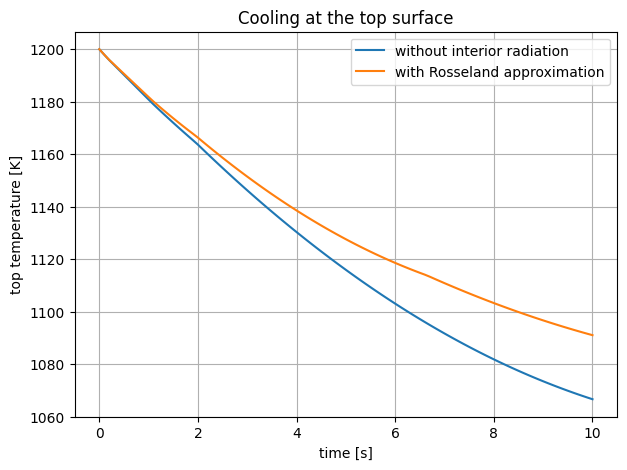

Top temperature after 10 s without interior radiation:
1066.648834388524
Top temperature after 10 s with Rosseland approximation:
1091.0529640279349


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
H = 0.5
rho = 2.48e3
c = 840
kappa = 0.81

T0 = 1200
TB = 1200
Tinf = 300

w = 5
sigma = 5.67e-8
eps = 0.9

n_ref = 1.46
lam = 1000

# Grid
N = 200
dz = H / N
z = (np.arange(N) + 0.5) * dz

def k_rad(T):
    return 16 * n_ref**2 * sigma * T**3 / (3 * lam)

def solve_model(use_rosseland=False):
    U_init = np.ones(N) * T0

    def rhs(t, U):
        flux = np.zeros(N + 1)

        # bottom boundary: U(0) = TB
        if use_rosseland:
            k_bottom = kappa + k_rad(0.5 * (U[0] + TB))
        else:
            k_bottom = kappa

        flux[0] = -k_bottom * (U[0] - TB) / (0.5 * dz)

        # interior fluxes
        for i in range(1, N):
            if use_rosseland:
                k_left = kappa + k_rad(U[i - 1])
                k_right = kappa + k_rad(U[i])
                k_face = 0.5 * (k_left + k_right)
            else:
                k_face = kappa

            flux[i] = -k_face * (U[i] - U[i - 1]) / dz

        # top boundary: cooling by convection and radiation
        U_top = U[-1]
        flux[N] = (
            w * (U_top - Tinf)
            + sigma * eps * (U_top**4 - Tinf**4)
        )

        # finite volume update
        dUdt = -(flux[1:] - flux[:-1]) / (rho * c * dz)

        return dUdt

    sol = solve_ivp(
        rhs,
        t_span=(0, 10),
        y0=U_init,
        method="BDF",
        t_eval=np.linspace(0, 10, 101)
    )

    return sol

sol_no_rad = solve_model(use_rosseland=False)
sol_rosseland = solve_model(use_rosseland=True)

# Plot final temperature profiles
plt.figure(figsize=(7, 5))
plt.plot(z, sol_no_rad.y[:, -1], label="without interior radiation")
plt.plot(z, sol_rosseland.y[:, -1], label="with Rosseland approximation")
plt.xlabel("z")
plt.ylabel("temperature U(t,z) [K]")
plt.title("Temperature profile at t = 10 s")
plt.legend()
plt.grid(True)
plt.show()

# Plot top temperature over time
plt.figure(figsize=(7, 5))
plt.plot(sol_no_rad.t, sol_no_rad.y[-1, :], label="without interior radiation")
plt.plot(sol_rosseland.t, sol_rosseland.y[-1, :], label="with Rosseland approximation")
plt.xlabel("time [s]")
plt.ylabel("top temperature [K]")
plt.title("Cooling at the top surface")
plt.legend()
plt.grid(True)
plt.show()

print("Top temperature after 10 s without interior radiation:")
print(sol_no_rad.y[-1, -1])

print("Top temperature after 10 s with Rosseland approximation:")
print(sol_rosseland.y[-1, -1])